<a href="https://colab.research.google.com/github/Chethana-0711/ML-LAB/blob/main/end_to_end_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chethana.C (1BM23CS077)

Dataset Shape: (20640, 9)

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitu

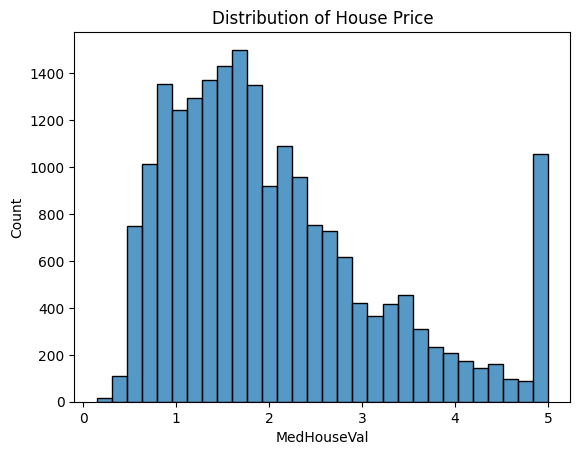

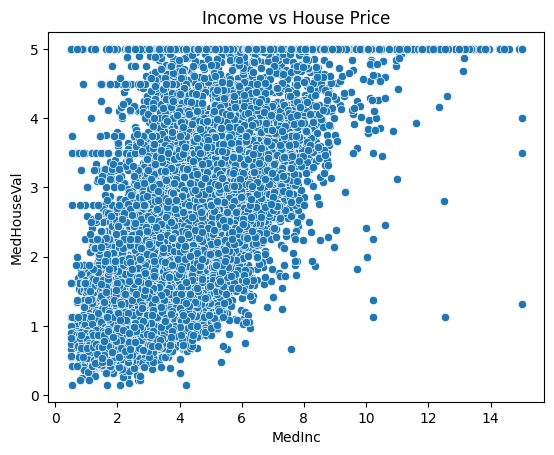

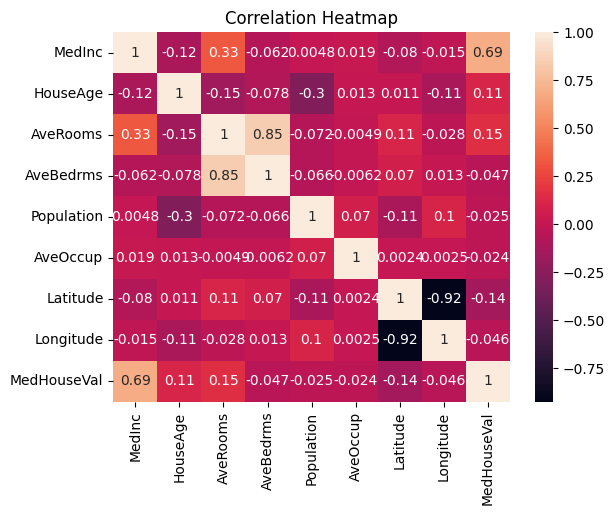


Observation: Median Income has strongest correlation with house price

Linear Regression:
RMSE: 0.7455813830127763
MAE: 0.5332001304956565
R2: 0.575787706032451

Decision Tree RMSE: 0.7028289572288925

Random Forest RMSE: 0.5051432839771741


In [ ]:


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Chethana.C (1BM23CS077)\n")

# -------------------------------
# Step 1: Load Data
# -------------------------------
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Dataset Shape:", df.shape)


# -------------------------------
# Step 2: Discover Data
# -------------------------------
print("\nMissing Values:\n", df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# -------------------------------
# Step 3: Visualize Data
# -------------------------------

# Distribution of house price
plt.figure()
sns.histplot(df['MedHouseVal'], bins=30)
plt.title("Distribution of House Price")
plt.show()

# Income vs House Price
plt.figure()
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'])
plt.title("Income vs House Price")
plt.show()

# Correlation Heatmap
plt.figure()
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\nObservation: Median Income has strongest correlation with house price")


# -------------------------------
# Step 4: Prepare Data
# -------------------------------
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# Step 5: Linear Regression
# -------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression:")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


# -------------------------------
# Step 6: Decision Tree
# -------------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("\nDecision Tree RMSE:", rmse_dt)


# -------------------------------
# Step 7: Random Forest
# -------------------------------
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nRandom Forest RMSE:", rmse_rf)


# -------------------------------
# Step 8: Hyperparameter Tuning
# -------------------------------
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='neg_mean_squared_error')

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("\nTuned Random Forest RMSE:", rmse_tuned)
print("Best Parameters:", grid.best_params_)


# -------------------------------
# Step 9: Model Comparison
# -------------------------------
print("\nModel Comparison (RMSE):")
print("Linear Regression:", rmse_lr)
print("Decision Tree:", rmse_dt)
print("Random Forest:", rmse_rf)
print("Tuned Random Forest:", rmse_tuned)


# -------------------------------
# Step 10: Best Model
# -------------------------------
print("\nBest Model:")
print("Random Forest performs best due to lowest RMSE")

print("\nWhy tuning helped?")
print("- Found optimal tree depth")
print("- Reduced overfitting")

print("\nAdditional Features to Improve Model:")
print("- Distance to city centers")
print("- Crime rate")
print("- School quality")